# Hisobga olinmagan suv: ma'lumotni tayyorlash va tahlil

[![Colab'da ochish](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adolatqodirova834-ui/california-water-loss-analysis/blob/main/waterloss.ipynb)

Kaliforniya suv resurslari departamentining suv yo'qotish auditlari.

Bu daftarda ma'lumot yuklanadi, tekshiriladi, tozalanadi, uch jadvalga
ajratiladi va tahlil qilinadi. Natija: uchta CSV fayl, ikkita grafik va
Excel pivot jadvallari uchun tayyorlangan fayl.

Manba: https://data.ca.gov/dataset/ca-urban-retail-water-system-water-loss-annual-loss-audit-data

Yuklab olingan sana: 2026-09-04


## 1. Kutubxonalar va ma'lumot


In [1]:
import pandas as pd            # jadval ko'rinishidagi ma'lumot bilan ishlash
import matplotlib.pyplot as plt  # grafik chizish


Ma'lumotni o'qiymiz. Ustunlar ko'p va turlari aralash, shuning uchun
`low_memory=False` beramiz: pandas butun faylni bir marta o'qib, turlarni
to'g'ri aniqlaydi.

Daftar Colab'da bo'sh sessiyada ham ishlashi kerak, shuning uchun fayl
topilmasa u manbadan avtomatik yuklab olinadi.


In [2]:
FAYL = "ca-retailer-waterlossdata.csv"
URL = "https://data.cnra.ca.gov/dataset/d6cdd89e-49b0-4b1f-86ee-8b7237e5f169/resource/058ac6ca-a8b4-4f28-b6c8-11e48309f3b4/download/ca-retailer-waterlossdata.csv"

# Avval yonimizdagi faylni o'qishga urinamiz. Topilmasa (masalan yangi
# Colab sessiyasida) manbadan o'qiymiz - pandas buni o'zi qila oladi.
try:
    df = pd.read_csv(FAYL, low_memory=False)
except FileNotFoundError:
    print("Fayl topilmadi, manbadan o'qilmoqda...")
    print("DIQQAT: manba har kuni yangilanadi, raqamlar farq qilishi mumkin.")
    df = pd.read_csv(URL, low_memory=False)

print("Qatorlar:", df.shape[0])
print("Ustunlar:", df.shape[1])


Qatorlar: 4924
Ustunlar: 190


Sana ustunlari matn sifatida o'qilgan. Ularni sana turiga o'tkazamiz,
aks holda ayirish va yil ajratish ishlamaydi.


In [3]:
# Sanalar CSV faylda oddiy matn. Ularni sana turiga o'tkazmasak,
# davr uzunligini hisoblab ham, yilni ajratib ham bo'lmaydi.
df["REPORTING_START_DATE"] = pd.to_datetime(df["REPORTING_START_DATE"])
df["REPORTING_END_DATE"] = pd.to_datetime(df["REPORTING_END_DATE"])


## 2. Dastlabki tekshiruv

Ishga kirishdan oldin ma'lumot yaroqli ekaniga ishonch hosil qilamiz.


In [4]:
print("Tizimlar:", df["PWS_ID_OR_OTHER_ID"].nunique())
print("Boshlanish:", df["REPORTING_START_DATE"].min())
print("Tugash:", df["REPORTING_START_DATE"].max())

# Bir tizim uchun bir davrda ikkita yozuv bormi
takror = df.duplicated(subset=["PWS_ID_OR_OTHER_ID", "REPORTING_START_DATE"])
print("Takroriy yozuvlar:", takror.sum())


Tizimlar: 609
Boshlanish: 2015-07-01 00:00:00
Tugash: 2025-01-01 00:00:00
Takroriy yozuvlar: 0


### Suv balansi tekshiruvi

AWWA metodikasiga ko'ra tizimga berilgan suv ruxsat etilgan iste'molga va
yo'qotishlarga bo'linadi. Ya'ni:

`berilgan - ruxsat etilgan = ko'rinma yo'qotish + real yo'qotish`

Bu tenglama bajarilishini tekshiramiz. Agar bajarilmasa, ma'lumot ichida
ziddiyat bor degani.


In [5]:
# Tenglamaning ikki tomonini alohida hisoblaymiz.
# Chap tomon: berilgan suvdan ruxsat etilgan iste'molni ayiramiz.
chap = df["WS_WATER_SUPPLIED_VOL_AF"] - df["AC_AUTH_CONSUMPTION_VOL_AF"]

# O'ng tomon: ikki turdagi yo'qotishning yig'indisi.
ong = df["WL_APPARENT_LOSSES_VOL_AF"] + df["WL_REAL_LOSSES_VOL_AF"]

# Farqning eng kattasi nolga yaqin bo'lishi kerak.
# abs() ishlatamiz, chunki chetlanish ikki tomonga ham bo'lishi mumkin.
print("Eng katta chetlanish:", (chap - ong).abs().max())


Eng katta chetlanish: 5.984475137665868e-10


Natija nolga juda yaqin. Bu kompyuterning kasr sonlarni saqlashdagi tabiiy
yaxlitlash xatosi. Demak barcha auditlarda suv balansi to'g'ri.


## 3. Birinchi jadval: systems

Xom faylda tizim nomi va shahri har bir audit qatorida takrorlanadi. Bu
ma'lumot yildan yilga o'zgarmaydi, shuning uchun uni alohida jadvalga
chiqaramiz va har bir tizimdan bitta qator qoldiramiz.

Sana bo'yicha tartiblab, **eng oxirgi** yozuvni qoldiramiz: tizim nomi
yillar davomida o'zgargan bo'lishi mumkin, bizga eng yangi nom kerak.


In [6]:
systems = df[[
    "PWS_ID_OR_OTHER_ID",
    "WATER_SUPPLIER_NAME",
    "CITY_TOWN_MUNICIPALITY",
    "WATER_SYSTEM_STRUCTURE",
    "WATER_TYPE",
    "REPORTING_START_DATE",
]]

systems = systems.sort_values("REPORTING_START_DATE")
systems = systems.drop_duplicates(subset="PWS_ID_OR_OTHER_ID", keep="last")

# Sana ustuni faqat tartiblash uchun kerak edi, endi olib tashlaymiz.
# Ustun nomlarini ham qisqartiramiz: uzun nomlar bilan ishlash noqulay.
systems = systems.drop(columns="REPORTING_START_DATE")
systems.columns = ["pws_id", "supplier_name", "city",
                   "system_structure", "water_type"]
systems = systems.reset_index(drop=True)

print("Tizimlar soni:", len(systems))
systems.head()


Tizimlar soni: 609


,pws_id,supplier_name,city,system_structure,water_type
0,CA1510038,Bear Valley Community Services District,Tehachapi,NaN,NaN
1,CA1910005,Los Angeles County Waterworks District 40 - An...,Lancaster/Palmdale,NaN,NaN
2,CA1910154,South Pasadena City Of,South Pasadena,NaN,NaN
3,CA5010005,Modesto City Of,City of Modesto,NaN,NaN
4,CA3610050,Upland City Of,Upland,Retail,Potable Water


## 4. Ikkinchi jadval: audits

Xom faylda 190 ustun bor, lekin ularning katta qismi izoh va takroriy
konvertatsiya ustunlari. Bizga 17 tasi kerak.

Lug'at tuzamiz: chapda manbadagi uzun nom, o'ngda bizning qisqa nomimiz.

`src_` bilan boshlanadigan uchta ustun manbaning o'zi hisoblagan
ko'rsatkichlar. Ularni tahlilda ishlatmaymiz, chunki o'zimiz hisoblaymiz.
Lekin saqlaymiz: o'z formulamizni tekshirish uchun kerak bo'ladi.


In [7]:
kerakli = {
    # Bog'lovchi va vaqt
    "PWS_ID_OR_OTHER_ID": "pws_id",
    "REPORTING_START_DATE": "period_start",
    "REPORTING_END_DATE": "period_end",
    # Hajmlar, akr-futda
    "WS_WATER_SUPPLIED_VOL_AF": "water_supplied_af",
    "AC_AUTH_CONSUMPTION_VOL_AF": "auth_consumption_af",
    "WL_APPARENT_LOSSES_VOL_AF": "apparent_losses_af",
    "WL_REAL_LOSSES_VOL_AF": "real_losses_af",
    "NRW_NON_REVENUE_WATER_VOL_AF": "nrw_af",
    # Tizim parametrlari
    "SD_NUM_SERVICE_CONN": "service_connections",
    "SD_LENGTH_MAINS_MILES": "mains_miles",
    "SD_AVG_OPER_PRESSURE_PSI": "avg_pressure_psi",
    "EST_POP_SERVED": "population_served",
    # Sifat va xarajat
    "WATER_AUDIT_VALIDITY_SCORE": "validity_score",
    "SA_REAL_LOSSES_ANN_COST": "real_losses_cost_usd",
    # Manbaning tayyor ko'rsatkichlari, faqat tekshirish uchun
    "PI_FI_NON_REV_PERCENT_BY_VOL": "src_nrw_percent",
    "PI_OE_REAL_LOSSES_GCD": "src_real_losses_gcd",
    "PI_INFRASTRUCT_LEAKAGE_INDEX": "src_ili",
}

audits = df[list(kerakli.keys())].rename(columns=kerakli).reset_index(drop=True)

# Har bir auditga 1 dan boshlab raqam beramiz.
# Bu birlamchi kalit bo'ladi va indicators jadvalini bog'lash uchun kerak.
audits.insert(0, "audit_id", range(1, len(audits) + 1))

print(audits.shape)
audits.head()


(4924, 18)


,audit_id,pws_id,period_start,period_end,water_supplied_af,auth_consumption_af,apparent_losses_af,real_losses_af,nrw_af,service_connections,mains_miles,avg_pressure_psi,population_served,validity_score,real_losses_cost_usd,src_nrw_percent,src_real_losses_gcd,src_ili
0,1,CA0110001,2016-01-01,2016-12-31,37846.798555,35855.157856,914.986137,1076.654562,2044.054235,84189.0,906.0587,75.000000,NaN,51.0,5.999174e+05,0.054009,11.416873,0.731065
1,2,CA0110001,2017-01-01,2017-12-31,41086.555391,37537.245174,1116.980208,2432.330009,3656.350690,84955.0,909.6000,70.419550,NaN,53.0,1.623864e+06,0.088991,25.559931,1.745668
2,3,CA0110001,2018-01-01,2018-12-31,42093.065741,38497.573566,964.521070,2630.971105,3717.804116,86250.0,946.8400,72.890000,NaN,56.0,1.561830e+06,0.088323,27.232223,1.784263
3,4,CA0110001,2019-01-01,2019-12-31,41451.347769,38035.259478,948.841188,2467.247103,3529.412892,85825.0,948.5000,72.928000,NaN,60.0,1.894013e+06,0.085146,25.664036,1.677444
4,5,CA0110001,2020-01-01,2020-12-31,44396.596889,40881.248392,1044.563668,2470.784829,3657.029531,86437.0,960.7200,72.764358,NaN,65.0,1.936469e+06,0.082372,25.518865,1.668990


## 5. Ko'rsatkichlarni hisoblash

**Audit davri necha kun.** Qat'iy 365 qo'ymaymiz: auditlarning hammasi ham
to'liq kalendar yilini qamramaydi, ba'zilari iyuldan iyulgacha boradi.


In [8]:
# Davr uzunligi. dt.days sana farqidan kunlar sonini oladi.
audits["kunlar"] = (audits["period_end"] - audits["period_start"]).dt.days

# describe() eng kichik, eng katta va o'rtacha qiymatni ko'rsatadi.
# Bu yerda kutilayotgani: 365 atrofida, lekin aynan emas.
audits["kunlar"].describe()


,kunlar
count,4924.000000
mean,364.344639
std,1.984305
min,334.000000
25%,364.000000
50%,364.000000
75%,365.000000
max,425.000000


**Birinchi ko'rsatkich: hisobga olinmagan suv foizi.** Hisobga olinmagan
suvni tizimga berilgan suvga bo'lib, 100 ga ko'paytiramiz.

**Ikkinchi ko'rsatkich: ulanish boshiga kunlik real yo'qotish.** Bu asosiy
ko'rsatkichimiz. Uch amalda hisoblanadi: akr-futni gallonga aylantiramiz
(1 akr-fut = 325 851 gallon), kunlar soniga bo'lamiz, keyin ulanishlar
soniga bo'lamiz.


In [9]:
# Birinchi ko'rsatkich: hisobga olinmagan suvning ulushi, foizda.
audits["nrw_percent"] = audits["nrw_af"] / audits["water_supplied_af"] * 100

# Ikkinchi ko'rsatkich: ulanish boshiga kunlik yo'qotish, gallonda.
# Uch amal ketma-ket bajariladi:
#   1) akr-futni gallonga aylantiramiz (1 akr-fut = 325 851 gallon)
#   2) davr kunlariga bo'lib, bir kunlik miqdorni topamiz
#   3) ulanishlar soniga bo'lib, bir ulanishga to'g'ri kelganini topamiz
audits["real_losses_gcd"] = (
    audits["real_losses_af"] * 325851
    / audits["kunlar"]
    / audits["service_connections"]
)

audits[["nrw_percent", "real_losses_gcd"]].describe()


,nrw_percent,real_losses_gcd
count,4924.000000,4924.000000
mean,11.815659,96.439608
std,10.743131,2231.417676
min,-11.232946,-4939.723174
25%,5.735850,14.522208
50%,8.782119,27.084763
75%,14.014903,48.060070
max,100.000000,148816.844459


## 6. Formulalarni tekshirish

Bu qadam majburiy. O'z hisobimizni manbadagi tayyor qiymatlar bilan
solishtiramiz. Agar mos kelsa, formulamiz to'g'ri.


In [10]:
# O'z hisobimizdan manbaning tayyor qiymatini ayiramiz.
# Formulamiz to'g'ri bo'lsa, farqning medianasi nolga yaqin chiqadi.
# Tekshiruvni filtrlashdan oldin, barcha auditlarda o'tkazamiz.
farq_gcd = audits["real_losses_gcd"] - audits["src_real_losses_gcd"]
print("gal/ulanish/kun farqi, mediana:", farq_gcd.median())

# Endi birinchi ko'rsatkichni tekshiramiz. Ikki ustunni yonma-yon
# qo'yib, ularning tarqalishini solishtiramiz.
audits[["nrw_percent", "src_nrw_percent"]].describe()


gal/ulanish/kun farqi, mediana: 0.04087484876359859


,nrw_percent,src_nrw_percent
count,4924.000000,3171.000000
mean,11.815659,0.117467
std,10.743131,0.111627
min,-11.232946,-0.112329
25%,5.735850,0.057268
50%,8.782119,0.087213
75%,14.014903,0.134624
max,100.000000,1.000000


### Aniqlangan muammo: birlik nomuvofiqligi

Ikki ustunni solishtiring. Bizniki medianada 8.78, manbaniki 0.087.
Maksimum: bizda 100, manbada 1.0. Har bir juftlikda aniq **100 barobar**
farq bor.

Sabab: ma'lumot lug'atida bu ustun foiz sifatida ta'riflangan, aslida esa
ulush sifatida saqlangan. Ya'ni hujjat va ma'lumot bir-biriga mos kelmaydi.

Agar biz manbaning tayyor ustunini tekshirmasdan ishlatganimizda, barcha
foizlarimiz yuz barobar kichik chiqar edi.


In [11]:
# Taqqoslashda birlikni tenglashtiramiz
farq_nrw = audits["nrw_percent"] - audits["src_nrw_percent"] * 100
print("NRW foizi farqi, mediana:", farq_nrw.median())


NRW foizi farqi, mediana: 3.552713678800501e-15


Ikkala formula ham tasdiqlandi.

## 7. Uchinchi jadval: indicators

Hisoblangan ko'rsatkichlarni alohida jadvalga chiqaramiz. Nega alohida:
xom ma'lumot va bizning hisobimiz aralashmasligi kerak. Kimdir natijani
tekshirmoqchi bo'lsa, manba qiymatlarini ko'ra oladi.


In [12]:
# Faqat uchta ustun: bog'lovchi kalit va ikkita hisoblangan ko'rsatkich.
# Xom ma'lumot audits jadvalida qoladi, bu yerda faqat bizning hisobimiz.
indicators = audits[["audit_id", "nrw_percent", "real_losses_gcd"]]
print(indicators.shape)


(4924, 3)


## 8. Chegaralarni qo'llash

Tahlil faqat taqqoslanadigan tizimlar bo'yicha olib boriladi. Ikkita
chegara qo'llaymiz.

**Ulanish zichligi 30 dan yuqori.** Zichlik bu bir mil quvurga to'g'ri
keladigan ulanishlar soni. AWWA qoidasiga ko'ra zichligi past tizimlarda
ulanish boshiga hisoblash yaroqsiz natija beradi. Masalan ulgurji
ta'minotchilarda quvur o'nlab mil, ulanishlar esa bir necha o'nta, va
ko'rsatkich kuniga 148 000 gallonga yetadi.

**Ulanishlar soni 3000 dan ko'p.** Kaliforniya qonunchiligida aynan shu
son yirik chakana ta'minotchini belgilaydi. Kichik tizimlarda barcha
ko'rsatkichlar beqaror bo'ladi.


In [13]:
# Zichlik: bir mil quvurga to'g'ri keladigan ulanishlar soni.
audits["zichlik"] = audits["service_connections"] / audits["mains_miles"]

# Uchta shartni birlashtiramiz. & belgisi "va" degani, har bir shart
# alohida qavs ichida bo'lishi shart.
# Birinchi shart nolga bo'linishdan himoya qiladi.
shart = ((audits["mains_miles"] > 0)
         & (audits["zichlik"] >= 30)
         & (audits["service_connections"] >= 3000))

# .copy() beramiz: keyinchalik bu jadvalga yangi ustun qo'shamiz,
# nusxa bo'lmasa pandas ogohlantirish beradi.
audits_toza = audits[shart].copy()

# indicators ni ham xuddi shu auditlar bo'yicha kesamiz,
# aks holda ikki jadval bir-biriga mos kelmaydi.
indicators_toza = indicators[indicators["audit_id"].isin(audits_toza["audit_id"])]

print("Chegaradan o'tgan auditlar:", len(audits_toza))
print("Tizimlar:", audits_toza["pws_id"].nunique())


Chegaradan o'tgan auditlar: 3541
Tizimlar: 428


Chegarani asoslash uchun ikki guruhni taqqoslaymiz.


In [14]:
# Guruh nomini qaytaradigan oddiy funksiya.
def tur_nomi(zichlik):
    if zichlik < 30:
        return "ulgurji (zichlik < 30)"
    else:
        return "chakana (zichlik >= 30)"

# Quvur uzunligi ko'rsatilgan auditlarni ajratamiz va guruh ustunini yasaymiz.
bor = audits[audits["mains_miles"] > 0].copy()
bor["turi"] = bor["zichlik"].apply(tur_nomi)

bor.groupby("turi").agg(
    auditlar=("audit_id", "count"),
    tizimlar=("pws_id", "nunique"),
    ortacha_gcd=("real_losses_gcd", "mean")).round(1)


,auditlar,tizimlar,ortacha_gcd
turi,,,
chakana (zichlik >= 30),4524,560,37.4
ulgurji (zichlik < 30),400,79,764.2


## 9. Tahlil

Tizim nomi kerak bo'lgani uchun `systems` bilan birlashtiramiz.


In [15]:
# Tahlilda tizim nomi kerak, u esa systems jadvalida.
# merge ikki jadvalni umumiy ustun (pws_id) orqali birlashtiradi.
tahlil = audits_toza.merge(systems[["pws_id", "supplier_name"]], on="pws_id")

# Yil ustuni: yillik guruhlash uchun kerak.
tahlil["yil"] = tahlil["period_start"].dt.year

# Qatorlar soni o'zgarmagan bo'lishi kerak: har bir pws_id systems
# jadvalida bir marta uchraydi, shuning uchun takrorlanish yo'q.
print(tahlil.shape)


(3541, 24)


### Taqsimot: o'rtacha tipik holatni ko'rsatmaydi


In [16]:
q = tahlil["real_losses_gcd"]

# O'rtacha va median bir-biridan uzoq bo'lsa, taqsimot nosimmetrik.
# quantile(0.9) qiymatlarning 90 foizi qaysi chegaradan pastda
# ekanini ko'rsatadi.
print("O'rtacha:      ", round(q.mean(), 1))
print("Median:        ", round(q.median(), 1))
print("90-protsentil: ", round(q.quantile(0.9), 1))
print("Maksimum:      ", round(q.max(), 1))


O'rtacha:       32.1
Median:         24.3
90-protsentil:  65.2
Maksimum:       505.3


Taqsimot o'ngga kuchli cho'zilgan. Guruhlar taqqoslanganda o'rtacha,
tipik holat tavsiflanganda median ishlatiladi.

### Ikki ko'rsatkich bir-birini almashtira oladimi


In [17]:
# Ikki xil bog'liqlik o'lchovi.
# Pearson to'g'ri chiziqli bog'liqlikni o'lchaydi.
# Spearman o'rinlar bo'yicha o'lchaydi, ya'ni reyting uchun aynan shu kerak.
# Ikkalasi ham -1 dan 1 gacha; 1 ga yaqin bo'lsa bog'liqlik kuchli.
p = tahlil["nrw_percent"].corr(tahlil["real_losses_gcd"])
s = tahlil["nrw_percent"].corr(tahlil["real_losses_gcd"], method="spearman")
print(f"Pearson:  {p:.2f}")
print(f"Spearman: {s:.2f}")

# Bog'liqlik kuchli bo'lsa ham, aniqlik yetarli bo'lmasligi mumkin.
# Buni tekshirish uchun tor kesma olamiz: foizi deyarli bir xil bo'lgan
# auditlarda ikkinchi ko'rsatkich qanchalik tarqalgan?
kesma = tahlil[(tahlil["nrw_percent"] >= 9) & (tahlil["nrw_percent"] <= 11)]
print("\n9-11% oralig'idagi auditlar:", len(kesma))
print(kesma["real_losses_gcd"].describe().round(1))


Pearson:  0.77
Spearman: 0.81

9-11% oralig'idagi auditlar: 438
count    438.0
mean      35.0
std       20.6
min        0.0
25%       25.4
50%       33.5
75%       41.8
max      304.8
Name: real_losses_gcd, dtype: float64


Bog'liqlik kuchli (Spearman 0.81), lekin tarqoqlik katta: bir xil foizga
ega tizimlarning yarmi 25 dan 42 gallongacha oraliqda. Foiz umumiy
yo'nalishni ko'rsatadi, alohida tizimning o'rnini emas.

### Reytinglar bir-biriga mos kelmaydi


In [18]:
# Har bir tizim uchun ikkala ko'rsatkichning yillar bo'yicha o'rtachasi.
# groupby ikkita ustun bo'yicha guruhlaydi: pws_id kalit, nom esa o'qish uchun.
tizim = tahlil.groupby(["pws_id", "supplier_name"]).agg(
    nrw=("nrw_percent", "mean"),
    gcd=("real_losses_gcd", "mean")).reset_index()

# rank o'rin beradi. ascending=False: eng katta qiymat 1-o'rinni oladi,
# ya'ni 1-o'rin "eng ko'p yo'qotadigan" degani.
tizim["orin_foiz"] = tizim["nrw"].rank(ascending=False)
tizim["orin_gallon"] = tizim["gcd"].rank(ascending=False)

# Ikki o'rin orasidagi masofa. abs() yo'nalishni e'tiborsiz qoldiradi:
# bizga siljish qaysi tomonga emas, qanchaligi muhim.
tizim["farq"] = (tizim["orin_foiz"] - tizim["orin_gallon"]).abs()

tizim.nlargest(10, "farq")[
    ["supplier_name", "nrw", "gcd", "orin_foiz", "orin_gallon", "farq"]].round(1)


,supplier_name,nrw,gcd,orin_foiz,orin_gallon,farq
256,Big Bear Community Services District,15.0,12.5,51.0,368.0,317.0
17,Antioch City Of,14.0,11.9,61.0,373.0,312.0
320,Cambria Community Service District,15.6,13.5,48.0,360.0,312.0
404,Groveland Community Services District,20.6,16.1,22.0,326.0,304.0
156,Livingston City Of,6.1,74.7,311.0,28.0,283.0
271,Big Bear Lake City Of,11.2,10.6,105.0,384.0,279.0
260,Crestline Village Water District,10.1,9.5,133.0,394.0,261.0
13,Del Oro Water Company,21.6,20.5,21.0,269.0,248.0
255,Lake Arrowhead Community Services District,15.0,18.6,53.0,298.0,245.0
277,Running Springs Water District,9.7,10.4,144.0,388.0,244.0


### Uchinchi ko'rsatkich: ILI

ILI (Infrastructure Leakage Index) real yo'qotishning texnik minimumga
nisbati. Minimum UARL tenglamasi bilan hisoblanadi va u quvur uzunligi,
ulanishlar soni va bosimni hisobga oladi.

Nima uchun kerak: gal/ulanish/kun bosimni ham, tarmoq geometriyasini ham
hisobga olmaydi. Yuqori bosimdagi tarmoq tabiiy ravishda ko'proq sizadi -
bu boshqaruv sifati emas, jismoniy qonuniyat. ILI shu ikkisini bo'luvchiga
kiritadi, ya'ni boshqaruv sifatini o'lchaydi.

Qiymat birliksiz: 1 texnik minimum, 4 esa minimumdan to'rt barobar ko'p
yo'qotish degani.

Manba faylida ILI tayyor keladi, qayta hisoblash shart emas.


In [19]:
# ILI birliksiz nisbat: 1 texnik minimum, 4 esa minimumdan
# to'rt barobar ko'p yo'qotish degani.
print(tahlil["src_ili"].describe().round(2))
print()
print("Bo'sh qiymatlar:", tahlil["src_ili"].isna().sum())

# Manfiy ILI jismonan mumkin emas. Uni alohida sanaymiz.
print("ILI < 0:", (tahlil["src_ili"] < 0).sum())
print("ILI < 1:", (tahlil["src_ili"] < 1).sum())


count    3541.00
mean        2.02
std         2.55
min        -5.51
25%         0.77
50%         1.38
75%         2.44
max        42.16
Name: src_ili, dtype: float64

Bo'sh qiymatlar: 0
ILI < 0: 40
ILI < 1: 1200


### Uch ko'rsatkich, uch reyting

Asosiy savol: mablag' eng yomon 20 talikka berilsa, o'sha ro'yxat qaysi
ko'rsatkich tanlanganiga qarab qanchalik o'zgaradi? Bu yerda butun
reytingdagi siljish emas, aynan tepadagi ustma-ustlik muhim - chunki
qaror shu ro'yxat bo'yicha qabul qilinadi.


In [20]:
tizim3 = tahlil.groupby(["pws_id", "supplier_name"]).agg(
    nrw=("nrw_percent", "mean"),
    gcd=("real_losses_gcd", "mean"),
    ili=("src_ili", "mean")).reset_index()

# ILI bo'sh bo'lgan tizimlarni chiqaramiz, aks holda taqqoslash noto'g'ri.
tizim3 = tizim3.dropna(subset=["ili"])
tizim3 = tizim3[tizim3["ili"] > 0]
print("Uchala ko'rsatkich mavjud tizimlar:", len(tizim3))
print()

def eng_yomon(ustun, n):
    return set(tizim3.nlargest(n, ustun)["pws_id"])

for n in [10, 20, 50]:
    a = eng_yomon("nrw", n)
    b = eng_yomon("gcd", n)
    c = eng_yomon("ili", n)
    print(f"Eng yomon {n} talik:")
    print(f"   uchala ko'rsatkichda ham: {len(a & b & c)}")
    print(f"   foiz va gallon:           {len(a & b)}")
    print(f"   gallon va ILI:            {len(b & c)}")


Uchala ko'rsatkich mavjud tizimlar: 428

Eng yomon 10 talik:
   uchala ko'rsatkichda ham: 3
   foiz va gallon:           5
   gallon va ILI:            6
Eng yomon 20 talik:
   uchala ko'rsatkichda ham: 5
   foiz va gallon:           7
   gallon va ILI:            16
Eng yomon 50 talik:
   uchala ko'rsatkichda ham: 24
   foiz va gallon:           32
   gallon va ILI:            37


### Audit ishonchliligi va o'lchangan yo'qotish


In [21]:
# Ballni uch guruhga ajratadigan funksiya.
def ball_guruhi(ball):
    if ball < 50:
        return "past (<50)"
    elif ball < 70:
        return "o'rta (50-69)"
    else:
        return "yuqori (70+)"

tahlil["ball_guruhi"] = tahlil["validity_score"].apply(ball_guruhi)

# Har bir guruh uchun o'rtacha ham, median ham chiqaramiz:
# ikkalasi bir yo'nalishni ko'rsatsa, natija ishonchliroq.
tahlil.groupby("ball_guruhi").agg(
    auditlar=("audit_id", "count"),
    ortacha=("real_losses_gcd", "mean"),
    median=("real_losses_gcd", "median"),
    nrw=("nrw_percent", "mean")).round(1)


,auditlar,ortacha,median,nrw
ball_guruhi,,,,
o'rta (50-69),2200,34.3,26.0,9.8
past (<50),165,47.7,33.5,13.1
yuqori (70+),1176,25.7,20.8,7.6


Bog'liqlik ikkala o'lchovda ham bir yo'nalishda, lekin kuchi farq qiladi.
Sababi bu ma'lumot bilan aniqlanmaydi: ikkita tushuntirish bir xil naqshni
beradi.

### Yillar bo'yicha o'zgarish

2015 (6 audit) va 2025 chiqariladi: birinchisida ma'lumot yig'ish endi
boshlangan, ikkinchisi hali yopilmagan.


In [22]:
# 2015 va 2025 ni chiqaramiz: birinchisida ma'lumot yig'ish endi
# boshlangan, ikkinchisi hali to'liq yopilmagan. Ular kiritilsa
# tendentsiya sun'iy ravishda buziladi.
yillik = tahlil[(tahlil["yil"] >= 2016) & (tahlil["yil"] <= 2024)]

yillik.groupby("yil").agg(
    auditlar=("audit_id", "count"),
    gcd=("real_losses_gcd", "mean"),
    nrw=("nrw_percent", "mean"),
    ball=("validity_score", "mean")).round(1)


,auditlar,gcd,nrw,ball
yil,,,,
2016,396,33.7,9.4,61.1
2017,394,34.6,9.6,62.8
2018,402,31.4,9.1,64.0
2019,394,31.5,9.3,65.4
2020,389,34.7,9.4,65.7
2021,390,28.8,8.5,66.2
2022,387,29.9,8.8,64.4
2023,388,30.8,9.5,65.6
2024,375,33.0,9.6,66.1


Yo'qotishda tendentsiya yo'q, ishonchlilik balli esa oshgan.
O'lchashning o'zi yo'qotishni kamaytirmaydi.

### Pul qiymati bo'yicha reyting


In [23]:
# Bu yerda sum ishlatiladi, mean emas: savol "to'qqiz yilda jami qancha
# pul yo'qoldi" degani. Shuning uchun ko'p audit topshirgan tizim
# tabiiy ravishda yuqoriroq chiqadi - auditlar ustunini shu uchun
# yonida ko'rsatamiz.
tahlil.groupby("supplier_name").agg(
    zarar_usd=("real_losses_cost_usd", "sum"),
    auditlar=("audit_id", "count"),
    ortacha_gcd=("real_losses_gcd", "mean")).round(1).nlargest(10, "zarar_usd")


,zarar_usd,auditlar,ortacha_gcd
supplier_name,,,
Los Angeles City Department Of Water And Power,251590924.3,9,32.0
San Diego City Of,172140093.5,8,37.5
San Jose Water Company,87585269.2,9,24.4
San Francisco Public Utilities Commission,52510462.4,9,28.1
Eastern Municipal Water District,43752589.8,10,24.3
Stockton City Of,33659512.7,13,56.5
Rancho California Water District,31642585.6,10,45.7
Irvine Ranch Water District,24830038.4,9,17.3
Oceanside City Of,20051630.8,10,26.4


### Shubhali qiymatlar


In [24]:
print("Manfiy NRW:       ", (tahlil["nrw_percent"] < 0).sum())
print("Manfiy yo'qotish: ", (tahlil["real_losses_af"] < 0).sum())
print("Aniq 100% NRW:    ", (tahlil["nrw_percent"] >= 99.9).sum())

# Manfiy qiymatli auditlarning ishonchlilik balli past emas
manfiy = tahlil[(tahlil["nrw_percent"] < 0) | (tahlil["real_losses_af"] < 0)]
print("\nManfiy auditlar ballining medianasi:", manfiy["validity_score"].median())
print("Umumiy median:                       ", tahlil["validity_score"].median())


Manfiy NRW:        15
Manfiy yo'qotish:  40
Aniq 100% NRW:     0

Manfiy auditlar ballining medianasi: 64.5
Umumiy median:                        65.0


## 10. Grafiklar

Ikki grafik chiziladi. Ular Power BI panelidagi grafiklarni takrorlamaydi,
balki metodologik qarorlarni asoslaydi.

**Birinchisi: taqsimot.** Nima uchun median tanlangani shu yerda ko'rinadi.


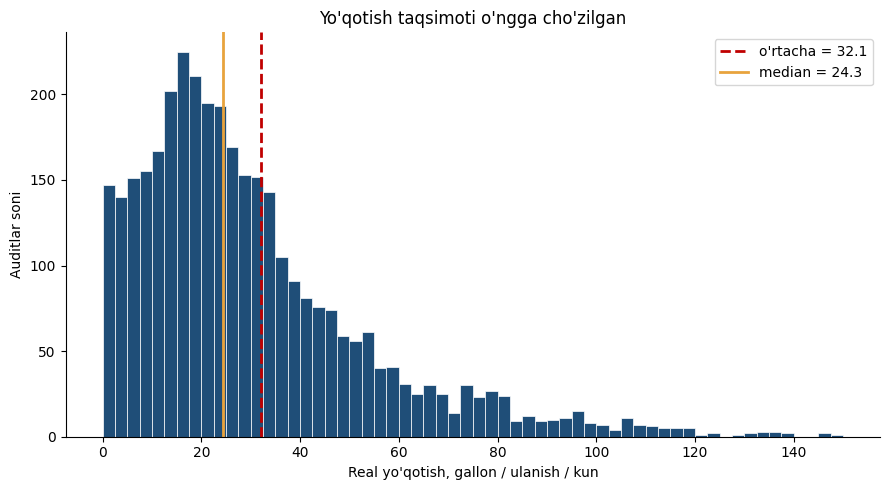

In [25]:
# Grafik hujayrasi mustaqil ishlashi uchun qiymatlarni shu yerda olamiz.
q = tahlil["real_losses_gcd"]
ortacha, median = q.mean(), q.median()

fig, ax = plt.subplots(figsize=(9, 5))

# bins=60: ustunlar soni. range=(0, 150): ko'rinish oralig'i.
# Nega 150 da to'xtatamiz: qiymatlarning 97 foizi shu yerda. To'liq
# oraliq (505 gacha) olinsa, chapdagi asosiy to'planish bir-ikki
# ustunga siqilib qoladi va shakl ko'rinmaydi.
ax.hist(q, bins=60, range=(0, 150), color="#1f4e78",
        edgecolor="white", linewidth=0.5)

# Ikki vertikal chiziq. Ular orasidagi masofa - taqsimot qanchalik
# nosimmetrik ekanining ko'rsatkichi.
ax.axvline(ortacha, color="#c00000", linestyle="--", linewidth=2,
           label=f"o'rtacha = {ortacha:.1f}")
ax.axvline(median, color="#e8a33d", linestyle="-", linewidth=2,
           label=f"median = {median:.1f}")

ax.set_xlabel("Real yo'qotish, gallon / ulanish / kun")
ax.set_ylabel("Auditlar soni")
ax.set_title("Yo'qotish taqsimoti o'ngga cho'zilgan")
ax.legend()

# Yuqori va o'ng ramkalar ma'lumot tashimaydi, olib tashlaymiz.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("taqsimot.png", dpi=150)
plt.show()


**Ikkinchisi: sochma diagramma.** Ikki ko'rsatkich o'rtasidagi bog'liqlik
va uning tarqoqligi.

`alpha` shaffoflik beradi: 3541 nuqta bir-birining ustiga tushadi,
shaffoflik bo'lmasa zich joy ham, siyrak joy ham bir xil dog' bo'lib
chiqadi.


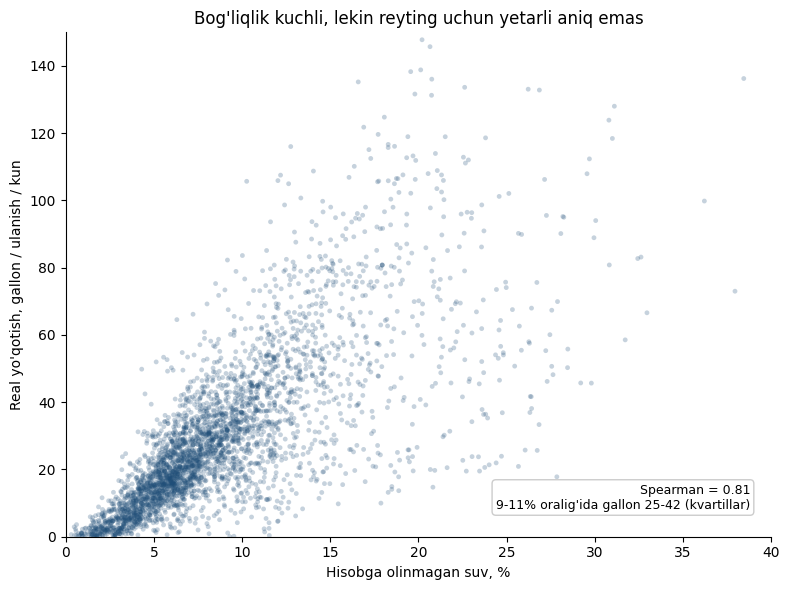

In [26]:
# Bu hujayra ham mustaqil ishlashi uchun Spearman'ni qayta hisoblaymiz.
s = tahlil["nrw_percent"].corr(tahlil["real_losses_gcd"], method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))

# alpha=0.25 - nuqtalar yarim shaffof. 3541 nuqta bir-birining ustiga
# tushadi; shaffoflik bo'lmasa zich joy ham, siyrak joy ham bir xil
# qora dog' bo'lib chiqadi. s=12 - nuqta o'lchami.
ax.scatter(tahlil["nrw_percent"], tahlil["real_losses_gcd"],
           s=12, alpha=0.25, color="#1f4e78", edgecolors="none")

# Chekka qiymatlar bulutni siqib qo'ymasligi uchun o'qlarni cheklaymiz.
ax.set_xlim(0, 40)
ax.set_ylim(0, 150)

ax.set_xlabel("Hisobga olinmagan suv, %")
ax.set_ylabel("Real yo'qotish, gallon / ulanish / kun")
ax.set_title("Bog'liqlik kuchli, lekin reyting uchun yetarli aniq emas")

# transform=ax.transAxes: koordinatalar 0 dan 1 gacha o'lchanadi,
# ya'ni matn ma'lumot qiymatlariga emas, grafik burchagiga bog'lanadi.
ax.text(0.97, 0.05,
        f"Spearman = {s:.2f}\n9-11% oralig'ida gallon 25-42 (kvartillar)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("sochma.png", dpi=150)
plt.show()


## 11. Saqlash

Hisoblash paytida qo'shilgan yordamchi ustunlar (`kunlar`, `zichlik`)
saqlanmaydi.


In [27]:
# Saqlanadigan ustunlar. Hisoblash paytida qo'shilgan yordamchi
# ustunlar (kunlar, zichlik) bu ro'yxatga kirmaydi - ular oraliq
# natija, faylda kerak emas.
audits_ustunlar = [
    "audit_id", "pws_id", "period_start", "period_end",
    "water_supplied_af", "auth_consumption_af",
    "apparent_losses_af", "real_losses_af", "nrw_af",
    "service_connections", "mains_miles", "avg_pressure_psi",
    "population_served", "validity_score", "real_losses_cost_usd",
    "src_nrw_percent", "src_real_losses_gcd", "src_ili",
]

# index=False: pandas'ning ichki qator raqamlari faylga tushmasin.
systems.to_csv("systems.csv", index=False)
audits_toza[audits_ustunlar].to_csv("audits.csv", index=False)
indicators_toza.to_csv("indicators.csv", index=False)

print("Uchta fayl saqlandi")


Uchta fayl saqlandi


Excel pivot jadvallari uchun alohida fayl: bir jadvalda barcha kerakli
ustunlar, chunki pivot bitta manba varag'idan ishlaydi.


In [28]:
# Excel pivot jadvali bitta manba varag'idan ishlaydi, shuning uchun
# bu yerda uchta jadval emas, bitta keng jadval saqlanadi.
excel_ustunlar = [
    "audit_id", "pws_id", "period_start", "service_connections",
    "mains_miles", "validity_score", "real_losses_af",
    "real_losses_cost_usd", "nrw_percent", "real_losses_gcd", "src_ili",
    "supplier_name", "yil",
]

tahlil[excel_ustunlar].to_csv("excel_uchun.csv", index=False)
print("excel_uchun.csv saqlandi:", tahlil.shape[0], "qator")


excel_uchun.csv saqlandi: 3541 qator


## Natija

| Fayl | Qatorlar | Nima |
|---|---|---|
| `systems.csv` | 609 | Tizimlar ro'yxati |
| `audits.csv` | 3541 | Chegaradan o'tgan auditlar |
| `indicators.csv` | 3541 | Hisoblangan ko'rsatkichlar |
| `excel_uchun.csv` | 3541 | Pivot jadvallar uchun yagona jadval |
| `taqsimot.png` | — | Yo'qotish taqsimoti |
| `sochma.png` | — | Ikki ko'rsatkich bog'liqligi |

Keyingi bosqich: Excel pivot jadvallari (`pivot_tahlil.xlsx`) va
Power BI paneli.

### Bu daftarda aniqlangan narsalar

1. Barcha auditlarda suv balansi tenglamasi bajariladi
2. Manbadagi tayyor NRW ustuni lug'atdagi ta'rifga mos kelmaydi
   (foiz emas, ulush)
3. Mustaqil hisoblangan ikkala ko'rsatkich ham manba qiymatlari bilan
   mos keladi
4. Foiz va gal/ulanish/kun kuchli bog'liq (Spearman 0.81), lekin reyting
   uchun yetarli aniq emas
5. Eng yomon 20 talikda gal/ulanish/kun va ILI 16 ta tizimda mos keladi,
   foiz esa ikkalasidan ham chetda qoladi (7 va 6)
6. ILI auditlarning 34 foizida texnik minimumdan past chiqadi, 40 tasida
   manfiy - o'lchov noaniqligi qoldiq ko'rsatkichga yig'iladi
7. To'qqiz yilda yo'qotish kamaymagan, o'lchov sifati esa oshgan
